# 스마트 창고 출고 지연 예측 v5

### v4 → v5 주요 개선사항
1. **누적/롤링 피처** : cumsum, roll3, expanding, slot_idx, trend
2. **pack_utilization 임계점** : >0.95 비선형 점프 포착
3. **레이아웃 클러스터** : 미확인 레이아웃 50개 대응
4. **타겟 변환 개선** : log1p → sqrt + MAE objective (예측 범위 확장)
5. **CatBoost Optuna 튜닝** 추가
6. **4-모델 앙상블** : sqrt 3개 + log1p 1개 (다양성 확보)
7. **Quantile Mapping 후처리** : 예측 분포 보정

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import warnings
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED    = 42
N_FOLDS = 5
TARGET  = 'avg_delay_minutes_next_30m'
ID_COLS = ['ID', 'layout_id', 'scenario_id']

np.random.seed(SEED)
print('✅ 환경 설정 완료')

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 환경 설정 완료


## 1. 데이터 로드 + 레이아웃 클러스터

In [2]:
train  = pd.read_csv('./data/train.csv')
test   = pd.read_csv('./data/test.csv')
layout = pd.read_csv('./data/layout_info.csv')

layout_type_map = {v: i for i, v in enumerate(layout['layout_type'].unique())}
layout['layout_type_enc'] = layout['layout_type'].map(layout_type_map)

# [v5] 레이아웃 클러스터 (미확인 레이아웃 대응)
layout_num_cols = [
    'aisle_width_avg', 'intersection_count', 'one_way_ratio',
    'pack_station_count', 'charger_count', 'layout_compactness',
    'zone_dispersion', 'robot_total', 'floor_area_sqm', 'ceiling_height_m'
]
scaler = StandardScaler()
layout_scaled = scaler.fit_transform(layout[layout_num_cols].fillna(0))
kmeans = KMeans(n_clusters=15, random_state=SEED, n_init=20)
layout['layout_cluster'] = kmeans.fit_predict(layout_scaled)

train = train.merge(layout.drop(columns=['layout_type']), on='layout_id', how='left')
test  = test.merge(layout.drop(columns=['layout_type']),  on='layout_id', how='left')

unseen = set(test['layout_id'].unique()) - set(train['layout_id'].unique())
print(f'train: {train.shape}, test: {test.shape}')
print(f'미확인 레이아웃: {len(unseen)}개')

train: (250000, 109), test: (50000, 108)
미확인 레이아웃: 50개


## 2. 타겟 분석

In [3]:
print('=== 타겟 통계 ===')
print(train[TARGET].describe())
print(f'왜도: 원본={stats.skew(train[TARGET]):.2f}, sqrt={stats.skew(np.sqrt(train[TARGET].clip(0))):.2f}, log1p={stats.skew(np.log1p(train[TARGET])):.2f}')

=== 타겟 통계 ===
count    250000.000000
mean         18.962296
std          27.351374
min           0.000000
25%           4.278801
50%           9.032652
75%          25.791869
max         715.858119
Name: avg_delay_minutes_next_30m, dtype: float64
왜도: 원본=5.68, sqrt=1.47, log1p=0.08


## 3. 피처 엔지니어링 (v5 확장)

In [4]:
def engineer_features(df):
    d = df.copy()
    # ── ① 로봇 압박 ──
    d['charge_pressure']       = d['charge_queue_length'] / (d['charger_count'] + 1)
    d['active_robot_ratio']    = d['robot_active'] / (d['robot_total'] + 1)
    d['idle_robot_ratio']      = d['robot_idle'] / (d['robot_total'] + 1)
    d['low_batt_robot_count']  = d['low_battery_ratio'] * d['robot_active']
    d['battery_stress']        = (1 - d['battery_mean'] / 100) * d['battery_std']
    d['charge_inefficiency']   = (100 - d['charge_efficiency_pct']) / 100
    d['effective_robot_avail'] = d['robot_total'] - d['low_batt_robot_count'] - d['charge_queue_length']
    d['robot_fault_ratio']     = d['fault_count_15m'] / (d['robot_active'] + 1)
    # ── ② 병목 복합 ──
    d['incident_total_15m']    = d['blocked_path_15m'] + d['near_collision_15m'] + d['fault_count_15m']
    d['congestion_load']       = d['congestion_score'] * d['avg_trip_distance']
    d['wait_per_intersection'] = d['intersection_wait_time_avg'] / (d['intersection_count'] + 1)
    d['path_congestion_gap']   = d['path_optimization_score'] - d['congestion_score']
    d['aisle_density']         = d['aisle_traffic_score'] / (d['aisle_width_avg'] + 0.1)
    d['oneway_congestion']     = d['one_way_ratio'] * d['congestion_score']
    d['compact_congestion']    = d['layout_compactness'] * d['congestion_score']
    # ── ③ 주문 부하 ──
    d['order_complexity']      = d['unique_sku_15m'] * d['avg_items_per_order']
    d['urgent_heavy_ratio']    = d['urgent_order_ratio'] * d['heavy_item_ratio']
    d['effective_order_load']  = d['order_inflow_15m'] * (1 + d['urgent_order_ratio'])
    d['rework_pressure']       = d['return_order_ratio'] + d['replenishment_overlap']
    d['forecast_miss']         = 1 - d['daily_forecast_accuracy']
    d['pick_complexity']       = d['pick_list_length_avg'] * (1 - d['sku_concentration'])
    d['backorder_urgency']     = d['backorder_ratio'] * d['urgent_order_ratio']
    # ── ④ 설비 압박 ──
    d['dock_pack_util_avg']      = (d['pack_utilization'] + d['loading_dock_util'] + d['staging_area_util']) / 3
    d['orders_per_pack_station'] = d['order_inflow_15m'] / (d['pack_station_count'] + 1)
    d['orders_per_robot']        = d['order_inflow_15m'] / (d['robot_active'] + 1)
    d['robot_density']           = d['robot_total'] / (d['floor_area_sqm'] + 1)
    d['charger_robot_ratio']     = d['charger_count'] / (d['robot_total'] + 1)
    d['pack_area_pressure']      = d['pack_utilization'] * d['layout_compactness']
    d['dock_truck_bottleneck']   = d['loading_dock_util'] * d['outbound_truck_wait_min']
    # ── ⑤ 환경/시스템 ──
    d['temp_diff']             = abs(d['warehouse_temp_avg'] - d['external_temp_c'])
    d['heat_humidity_index']   = d['warehouse_temp_avg'] * d['humidity_pct'] / 100
    d['it_bottleneck']         = d['wms_response_time_ms'] * (1 + d['scanner_error_rate'])
    d['network_instability']   = d['network_latency_ms'] * (1 - d['wifi_signal_db'] / 100)
    d['barcode_fail_rate']     = 1 - d['barcode_read_success_rate']
    d['label_scan_bottleneck'] = d['label_print_queue'] * (1 + d['scanner_error_rate'])
    d['conveyor_load']         = d['avg_package_weight_kg'] / (d['conveyor_speed_mps'] + 0.01)
    # ── ⑥ 인력 ──
    d['orders_per_staff']      = d['order_inflow_15m'] / (d['staff_on_floor'] + 1)
    d['forklift_staff_ratio']  = d['forklift_active_count'] / (d['staff_on_floor'] + 1)
    d['shift_load_ratio']      = d['order_inflow_15m'] / (d['prev_shift_volume'] + 1)
    d['handover_pressure']     = d['shift_handover_delay_min'] * d['prev_shift_volume'] / 1000
    d['skilled_capacity']      = d['staff_on_floor'] * d['worker_avg_tenure_months']
    # ── ⑦ 시간 ──
    d['shift_hour_sin'] = np.sin(2 * np.pi * d['shift_hour'] / 24)
    d['shift_hour_cos'] = np.cos(2 * np.pi * d['shift_hour'] / 24)
    d['dow_sin']        = np.sin(2 * np.pi * d['day_of_week'] / 7)
    d['dow_cos']        = np.cos(2 * np.pi * d['day_of_week'] / 7)
    d['is_peak_hour']   = d['shift_hour'].isin([9,10,11,14,15,16,17]).astype(int)
    # ── ⑧ 레이아웃 ──
    d['age_maintenance_risk']    = d['building_age_years'] * (1 - d['maintenance_schedule_score'])
    d['vertical_gap']            = d['ceiling_height_m'] - d['racking_height_avg_m']
    d['dispersion_trip_cost']    = d['zone_dispersion'] * d['avg_trip_distance']
    d['crossdock_dock_pressure'] = d['cross_dock_ratio'] * d['loading_dock_util']
    d['cold_chain_risk']         = d['cold_chain_ratio'] * abs(d['cold_storage_temp_c'] + 18)
    d['area_per_robot']          = d['floor_area_sqm'] / (d['robot_total'] + 1)
    # ── ⑨ 교호 ──
    d['robot_order_congestion']  = d['orders_per_robot'] * d['congestion_score']
    d['battery_order_pressure']  = d['battery_stress'] * d['effective_order_load']
    d['it_order_bottleneck']     = d['it_bottleneck'] * d['order_inflow_15m'] / 1000
    d['super_traffic_jam_risk']  = d['sku_concentration'] * d['avg_trip_distance'] * d['layout_compactness']
    # ═══ [v5 NEW] ═══
    # ⑩ pack 비선형 임계점
    d['pack_saturated']         = (d['pack_utilization'] > 0.95).astype(int)
    d['pack_overflow_pressure'] = np.maximum(d['pack_utilization'] - 0.95, 0) * d['order_inflow_15m']
    d['pack_util_sq']           = d['pack_utilization'] ** 2
    d['pack_sat_x_orders']      = d['pack_saturated'] * d['orders_per_pack_station']
    d['pack_sat_x_congestion']  = d['pack_saturated'] * d['congestion_score']
    # ⑪ 레이아웃 교호 추가
    d['pack_station_x_compact']    = d['pack_station_count'] * d['layout_compactness']
    d['intersection_x_dispersion'] = d['intersection_count'] * d['zone_dispersion']
    d['robot_per_pack_station']    = d['robot_total'] / (d['pack_station_count'] + 1)
    d['charger_per_area']          = d['charger_count'] / (d['floor_area_sqm'] / 1000 + 1)
    # ⑫ 늦은 시간대
    d['is_late_peak']       = (d['shift_hour'] >= 18).astype(int)
    d['late_peak_x_order']  = d['is_late_peak'] * d['order_inflow_15m']
    d['late_peak_x_pack']   = d['is_late_peak'] * d['pack_utilization']
    # ⑬ 추가 교호
    d['order_per_robot_sq']    = d['orders_per_robot'] ** 2
    d['low_batt_x_congestion'] = d['low_battery_ratio'] * d['congestion_score']
    d['idle_x_order_load']     = d['idle_robot_ratio'] * d['effective_order_load']
    d['charge_q_x_orders']     = d['charge_queue_length'] * d['order_inflow_15m']
    d['robot_util_x_trip']     = d['robot_utilization'] * d['avg_trip_distance']
    return d

train_fe = engineer_features(train)
test_fe  = engineer_features(test)
print(f'피처 엔지니어링: {train_fe.shape}')

피처 엔지니어링: (250000, 182)


## 4. 래그 + 누적/롤링 피처 (v5)

In [5]:
LAG_COLS = [
    'order_inflow_15m', 'congestion_score', 'robot_active', 'robot_utilization',
    'battery_mean', 'charge_queue_length', 'blocked_path_15m', 'fault_count_15m',
    'pack_utilization', 'loading_dock_util', 'effective_order_load',
    'congestion_load', 'charge_pressure', 'orders_per_robot',
    'it_bottleneck', 'battery_stress',
]
CUM_COLS = ['order_inflow_15m','congestion_score','blocked_path_15m','fault_count_15m','near_collision_15m','incident_total_15m']
ROLL_COLS = ['order_inflow_15m','congestion_score','battery_mean','pack_utilization','robot_utilization','effective_order_load','loading_dock_util']

def add_temporal_features(df, lag_cols, cum_cols, roll_cols):
    d = df.copy().sort_values(['scenario_id','shift_hour']).reset_index(drop=True)
    # slot position
    d['slot_idx'] = d.groupby('scenario_id').cumcount()
    d['slot_progress'] = d['slot_idx'] / 24
    # lags
    for col in lag_cols:
        if col not in d.columns: continue
        l1 = d.groupby('scenario_id')[col].shift(1)
        l2 = d.groupby('scenario_id')[col].shift(2)
        d[f'{col}_lag1'] = l1
        d[f'{col}_lag2'] = l2
        d[f'{col}_diff1'] = d[col] - l1
    # cumsum
    for col in cum_cols:
        if col not in d.columns: continue
        d[f'{col}_cumsum'] = d.groupby('scenario_id')[col].cumsum()
    # rolling
    for col in roll_cols:
        if col not in d.columns: continue
        d[f'{col}_roll3_mean'] = d.groupby('scenario_id')[col].transform(lambda x: x.rolling(3, min_periods=1).mean())
        d[f'{col}_roll3_std']  = d.groupby('scenario_id')[col].transform(lambda x: x.rolling(3, min_periods=1).std())
    # expanding mean
    for col in ['order_inflow_15m','congestion_score','pack_utilization','battery_mean']:
        if col not in d.columns: continue
        d[f'{col}_exp_mean'] = d.groupby('scenario_id')[col].transform(lambda x: x.expanding().mean())
    # trend (3-slot slope)
    for col in ['order_inflow_15m','congestion_score','pack_utilization']:
        if col not in d.columns: continue
        def rolling_slope(x):
            out = np.full(len(x), np.nan); vals = x.values
            for i in range(2, len(vals)):
                y_v = vals[i-2:i+1]
                if np.all(np.isfinite(y_v)): out[i] = (y_v[2] - y_v[0]) / 2
            return pd.Series(out, index=x.index)
        d[f'{col}_trend3'] = d.groupby('scenario_id')[col].transform(rolling_slope)
    # pack lag thresholds
    if 'pack_utilization_lag1' in d.columns:
        d['pack_sat_lag1'] = (d['pack_utilization_lag1'] > 0.95).astype(int)
    if 'pack_utilization_lag2' in d.columns:
        d['pack_sat_lag2'] = (d['pack_utilization_lag2'] > 0.95).astype(int)
    # cumulative interactions
    if 'order_inflow_15m_cumsum' in d.columns:
        d['cum_order_per_robot'] = d['order_inflow_15m_cumsum'] / (d['robot_total'] + 1)
        d['cum_order_x_pack']   = d['order_inflow_15m_cumsum'] * d['pack_utilization']
    # fill NaN
    fill_cols = [c for c in d.columns if any(t in c for t in ['_lag','_diff','_cumsum','_roll3','_exp_','_trend','_sat_lag'])]
    for col in fill_cols:
        d[col] = d.groupby('scenario_id')[col].transform(lambda x: x.fillna(x.median()))
    d[fill_cols] = d[fill_cols].fillna(0)
    return d

train_fe = add_temporal_features(train_fe, LAG_COLS, CUM_COLS, ROLL_COLS)
test_fe  = add_temporal_features(test_fe,  LAG_COLS, CUM_COLS, ROLL_COLS)
print(f'전체 피처: {len([c for c in train_fe.columns if c not in ID_COLS + [TARGET]])}')

전체 피처: 259


## 4.5 [v5.3] 시나리오 전체 통계 피처 (확장)
v5.2 대비: 컬럼 12→18개, 집계 mean/std/max→+min/range, 교호작용, half_diff 확장

In [6]:
# [v5.3] 시나리오 전체 통계 피처 — 대폭 확장

# 기존 12개 + 신규 6개 = 18개 컬럼
SC_COLS_CORE = [
    'order_inflow_15m', 'congestion_score', 'robot_utilization', 'battery_mean',
    'pack_utilization', 'loading_dock_util', 'blocked_path_15m', 'fault_count_15m',
    'low_battery_ratio', 'charge_queue_length', 'robot_idle', 'near_collision_15m',
]
SC_COLS_NEW = [
    'max_zone_density',        # corr 0.39
    'avg_recovery_time',       # corr 0.38
    'battery_std',             # corr 0.39
    'replenishment_overlap',   # corr 0.36
    'robot_charging',          # corr 0.33
    'task_reassign_15m',       # corr 0.30
]
SC_COLS_ALL = SC_COLS_CORE + SC_COLS_NEW

def add_scenario_stats_v3(df, cols):
    d = df.copy()
    
    # ── mean, std, max, min, range ──
    for col in cols:
        if col not in d.columns:
            continue
        d[f'sc_{col}_mean']  = d.groupby('scenario_id')[col].transform('mean')
        d[f'sc_{col}_std']   = d.groupby('scenario_id')[col].transform('std')
        d[f'sc_{col}_max']   = d.groupby('scenario_id')[col].transform('max')
        d[f'sc_{col}_min']   = d.groupby('scenario_id')[col].transform('min')
        d[f'sc_{col}_range'] = d[f'sc_{col}_max'] - d[f'sc_{col}_min']
    
    # ── 전반부 vs 후반부 차이 (확장) ──
    d_sorted = d.sort_values(['scenario_id', 'shift_hour'])
    d['_slot'] = d_sorted.groupby('scenario_id').cumcount().values
    half_diff_cols = ['order_inflow_15m', 'congestion_score', 'robot_utilization',
                      'battery_mean', 'pack_utilization', 'low_battery_ratio']
    for col in half_diff_cols:
        if col not in d.columns:
            continue
        first_half = d[d['_slot'] < 12].groupby('scenario_id')[col].mean()
        second_half = d[d['_slot'] >= 12].groupby('scenario_id')[col].mean()
        half_diff = (second_half - first_half).rename(f'sc_{col}_half_diff')
        d = d.merge(half_diff.reset_index(), on='scenario_id', how='left')
    d = d.drop(columns=['_slot'])
    
    # ── 시나리오 통계 교호작용 (Top corr) ──
    if 'sc_battery_mean_mean' in d.columns and 'sc_low_battery_ratio_mean' in d.columns:
        d['sc_batt_x_lowbatt'] = d['sc_battery_mean_mean'] * d['sc_low_battery_ratio_mean']
    if 'sc_order_inflow_15m_mean' in d.columns and 'sc_robot_utilization_std' in d.columns:
        d['sc_order_x_robotstd'] = d['sc_order_inflow_15m_mean'] * d['sc_robot_utilization_std']
    if 'sc_robot_utilization_std' in d.columns and 'sc_fault_count_15m_max' in d.columns:
        d['sc_robotstd_x_fault'] = d['sc_robot_utilization_std'] * d['sc_fault_count_15m_max']
    if 'sc_order_inflow_15m_mean' in d.columns and 'sc_fault_count_15m_max' in d.columns:
        d['sc_order_x_fault'] = d['sc_order_inflow_15m_mean'] * d['sc_fault_count_15m_max']
    if 'sc_order_inflow_15m_mean' in d.columns and 'sc_pack_utilization_mean' in d.columns:
        d['sc_order_x_pack'] = d['sc_order_inflow_15m_mean'] * d['sc_pack_utilization_mean']
    if 'sc_congestion_score_mean' in d.columns and 'sc_robot_utilization_std' in d.columns:
        d['sc_cong_x_robotstd'] = d['sc_congestion_score_mean'] * d['sc_robot_utilization_std']
    
    # ── NaN 처리 ──
    sc_feat_cols = [c for c in d.columns if c.startswith('sc_')]
    d[sc_feat_cols] = d[sc_feat_cols].fillna(0)
    
    return d

train_fe = add_scenario_stats_v3(train_fe, SC_COLS_ALL)
test_fe  = add_scenario_stats_v3(test_fe, SC_COLS_ALL)

sc_count = len([c for c in train_fe.columns if c.startswith('sc_')])
print(f'시나리오 통계 피처: {sc_count}개 (v5.2: 39개 → v5.3: {sc_count}개)')
print(f'전체 피처 수: {len([c for c in train_fe.columns if c not in ID_COLS + [TARGET]])}')

시나리오 통계 피처: 102개 (v5.2: 39개 → v5.3: 102개)
전체 피처 수: 361


## 5. 타겟 인코딩

In [7]:
def target_encode_cv(train_df, test_df, col, target, n_splits=5, alpha=20):
    gm = train_df[target].mean(); enc = np.zeros(len(train_df))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    for ti, vi in kf.split(train_df):
        s = train_df.iloc[ti].groupby(col)[target].agg(['mean','count'])
        s['sm'] = (s['count']*s['mean']+alpha*gm)/(s['count']+alpha)
        enc[vi] = train_df.iloc[vi][col].map(s['sm']).fillna(gm)
    fs = train_df.groupby(col)[target].agg(['mean','count'])
    fs['sm'] = (fs['count']*fs['mean']+alpha*gm)/(fs['count']+alpha)
    te = test_df[col].map(fs['sm']).fillna(gm).values
    return enc, te

for col_name, feat_name in [('layout_id','te_layout_id'),('layout_type_enc','te_layout_type'),('layout_cluster','te_layout_cluster')]:
    tr_e, te_e = target_encode_cv(train_fe, test_fe, col_name, TARGET)
    train_fe[feat_name] = tr_e
    test_fe[feat_name]  = te_e
print('✅ 타겟 인코딩 완료 (layout_id, layout_type, layout_cluster)')

✅ 타겟 인코딩 완료 (layout_id, layout_type, layout_cluster)


## 6. 피처/타겟 준비

In [8]:
feature_cols = [c for c in train_fe.columns if c not in ID_COLS + [TARGET]]
for col in feature_cols:
    med = train_fe[col].median()
    train_fe[col] = train_fe[col].fillna(med)
    test_fe[col]  = test_fe[col].fillna(med)

X, y, X_test = train_fe[feature_cols].copy(), train_fe[TARGET].copy(), test_fe[feature_cols].copy()
y_tr_sqrt = np.sqrt(y.clip(lower=0))
y_tr_log  = np.log1p(y.clip(lower=0))

def decode_sqrt(p): return (p.clip(0))**2
def decode_log(p):  return np.expm1(p).clip(0)

gkf    = GroupKFold(n_splits=N_FOLDS)
groups = train_fe['scenario_id']
print(f'피처: {len(feature_cols)}, 왜도: 원본={stats.skew(y):.2f} → sqrt={stats.skew(y_tr_sqrt):.2f}')

피처: 364, 왜도: 원본=5.68 → sqrt=1.47


## 7. LGB Optuna 튜닝 (sqrt+MAE)

In [9]:
tidx = np.random.choice(len(X), 50000, replace=False)
Xt, yt_s, yt_r, gt = X.iloc[tidx].reset_index(drop=True), y_tr_sqrt.iloc[tidx].reset_index(drop=True), y.iloc[tidx].reset_index(drop=True), groups.iloc[tidx].reset_index(drop=True)

def lgb_obj(trial):
    p = dict(n_estimators=trial.suggest_int('n_estimators',500,3000), learning_rate=trial.suggest_float('learning_rate',0.01,0.1,log=True),
             max_depth=trial.suggest_int('max_depth',4,9), num_leaves=trial.suggest_int('num_leaves',31,255),
             subsample=trial.suggest_float('subsample',0.5,1.0), colsample_bytree=trial.suggest_float('colsample_bytree',0.4,1.0),
             reg_alpha=trial.suggest_float('reg_alpha',1e-4,10,log=True), reg_lambda=trial.suggest_float('reg_lambda',1e-4,10,log=True),
             min_child_samples=trial.suggest_int('min_child_samples',20,200))
    F = dict(objective='mae', device='gpu', random_state=SEED, verbose=-1)
    ms = []
    for ti, vi in GroupKFold(n_splits=3).split(Xt, yt_s, groups=gt):
        m = LGBMRegressor(**p, **F)
        m.fit(Xt.iloc[ti], yt_s.iloc[ti], eval_set=[(Xt.iloc[vi], yt_s.iloc[vi])], callbacks=[lgb.early_stopping(30,verbose=False), lgb.log_evaluation(-1)])
        ms.append(mean_absolute_error(yt_r.iloc[vi], decode_sqrt(m.predict(Xt.iloc[vi]))))
    return np.mean(ms)

print('🔍 LGB Optuna (50 trials)...')
study_lgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(lgb_obj, n_trials=50, show_progress_bar=True)
BEST_LGB = study_lgb.best_params
print(f'✅ LGB 최적 MAE: {study_lgb.best_value:.4f}')

🔍 LGB Optuna (50 trials)...


Best trial: 49. Best value: 8.82277: 100%|██████████| 50/50 [38:38<00:00, 46.37s/it]

✅ LGB 최적 MAE: 8.8228


## 8. [v5] CatBoost Optuna 튜닝

In [10]:
def cb_obj(trial):
    # 수정됨: colsample_bylevel 파라미터 제거
    p = dict(
        iterations=trial.suggest_int('iterations', 500, 3000), 
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        depth=trial.suggest_int('depth', 5, 10), 
        l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 0.1, 20, log=True),
        subsample=trial.suggest_float('subsample', 0.5, 1.0), 
        min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 10, 200)
    )
    F = dict(loss_function='MAE', eval_metric='MAE', bootstrap_type='Bernoulli', 
             random_seed=SEED, early_stopping_rounds=30, verbose=0, 
             task_type='GPU', devices='0')
    ms = []
    for ti, vi in GroupKFold(n_splits=3).split(Xt, yt_s, groups=gt):
        m = CatBoostRegressor(**p, **F)
        m.fit(Xt.iloc[ti], yt_s.iloc[ti], eval_set=(Xt.iloc[vi], yt_s.iloc[vi]))
        ms.append(mean_absolute_error(yt_r.iloc[vi], decode_sqrt(m.predict(Xt.iloc[vi]))))
    return np.mean(ms)

print('🔍 CB Optuna (30 trials)...')
study_cb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_cb.optimize(cb_obj, n_trials=30, show_progress_bar=True)
BEST_CB = study_cb.best_params
print(f'✅ CB 최적 MAE: {study_cb.best_value:.4f}')

🔍 CB Optuna (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Best trial: 0. Best value: 8.90393:   3%|▎         | 1/30 [02:57<1:25:41, 177.29s/it]Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Best trial: 0. Best value: 8.90393:   7%|▋         | 2/30 [04:51<1:05:23, 140.12s/it]Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU
Best trial: 0. Best value: 8.90393:  10%|█         | 3/30 [07:47<1:10:22, 156.39s/it]Default metric period is 5 because MAE is/are not implemented for GPU
Default

✅ CB 최적 MAE: 8.8776


## 9. LGB 5-Fold (sqrt)

In [11]:
oof_lgb, test_lgb, lgb_imp = np.zeros(len(X)), np.zeros(len(X_test)), np.zeros(len(feature_cols))
print('🚀 LGB 5-Fold (sqrt+MAE)\n')
for fold, (ti, vi) in enumerate(gkf.split(X, y, groups=groups)):
    print(f'── Fold {fold+1} ──')
    m = LGBMRegressor(**BEST_LGB, objective='mae', device='gpu', random_state=SEED, verbose=-1)
    m.fit(X.iloc[ti], y_tr_sqrt.iloc[ti], eval_set=[(X.iloc[vi], y_tr_sqrt.iloc[vi])],
          callbacks=[lgb.early_stopping(50,verbose=False), lgb.log_evaluation(200)])
    oof_lgb[vi] = decode_sqrt(m.predict(X.iloc[vi]))
    test_lgb   += decode_sqrt(m.predict(X_test)) / N_FOLDS
    lgb_imp    += m.feature_importances_ / N_FOLDS
    print(f'   MAE: {mean_absolute_error(y.iloc[vi], oof_lgb[vi]):.4f}\n')
print(f'📊 LGB(sqrt) OOF MAE: {mean_absolute_error(y, oof_lgb):.4f}')

🚀 LGB 5-Fold (sqrt+MAE)

── Fold 1 ──
[200]	valid_0's l1: 0.923561
[400]	valid_0's l1: 0.915501
[600]	valid_0's l1: 0.91496
   MAE: 8.7787

── Fold 2 ──
[200]	valid_0's l1: 0.926221
[400]	valid_0's l1: 0.918924
   MAE: 8.7422

── Fold 3 ──
[200]	valid_0's l1: 0.97015
[400]	valid_0's l1: 0.964662
   MAE: 9.2702

── Fold 4 ──
[200]	valid_0's l1: 0.896945
[400]	valid_0's l1: 0.885838
[600]	valid_0's l1: 0.883162
[800]	valid_0's l1: 0.882567
   MAE: 8.2296

── Fold 5 ──
[200]	valid_0's l1: 0.918025
[400]	valid_0's l1: 0.909642
[600]	valid_0's l1: 0.908382
   MAE: 8.6785

📊 LGB(sqrt) OOF MAE: 8.7398


## 10. CB 5-Fold (sqrt, 튜닝)

In [12]:
oof_cb, test_cb = np.zeros(len(X)), np.zeros(len(X_test))
print('🐱 CB 5-Fold (sqrt+MAE)\n')
for fold, (ti, vi) in enumerate(gkf.split(X, y, groups=groups)):
    print(f'── Fold {fold+1} ──')
    m = CatBoostRegressor(**BEST_CB, loss_function='MAE', eval_metric='MAE', bootstrap_type='Bernoulli',
                          random_seed=SEED, early_stopping_rounds=50, verbose=200, task_type='GPU', devices='0')
    m.fit(X.iloc[ti], y_tr_sqrt.iloc[ti], eval_set=(X.iloc[vi], y_tr_sqrt.iloc[vi]))
    oof_cb[vi] = decode_sqrt(m.predict(X.iloc[vi]))
    test_cb   += decode_sqrt(m.predict(X_test)) / N_FOLDS
    print(f'   MAE: {mean_absolute_error(y.iloc[vi], oof_cb[vi]):.4f}\n')
print(f'📊 CB(sqrt) OOF MAE: {mean_absolute_error(y, oof_cb):.4f}')

🐱 CB 5-Fold (sqrt+MAE)

── Fold 1 ──


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 1.7146686	test: 1.7185544	best: 1.7185544 (0)	total: 30.2ms	remaining: 1m 26s
200:	learn: 0.9316513	test: 0.9653937	best: 0.9653937 (200)	total: 5.96s	remaining: 1m 18s
400:	learn: 0.8371649	test: 0.9331763	best: 0.9331702 (399)	total: 12s	remaining: 1m 13s
600:	learn: 0.7673820	test: 0.9273399	best: 0.9273172 (599)	total: 18.1s	remaining: 1m 8s
800:	learn: 0.7074416	test: 0.9261609	best: 0.9259993 (780)	total: 24.2s	remaining: 1m 2s
1000:	learn: 0.6529580	test: 0.9250703	best: 0.9246973 (951)	total: 30.3s	remaining: 56.5s
bestTest = 0.9246972656
bestIteration = 951
Shrink model to first 952 iterations.
   MAE: 8.8779

── Fold 2 ──


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 1.7168525	test: 1.7100491	best: 1.7100491 (0)	total: 28.5ms	remaining: 1m 21s
200:	learn: 0.9343176	test: 0.9605173	best: 0.9605173 (200)	total: 5.83s	remaining: 1m 17s
400:	learn: 0.8313909	test: 0.9297133	best: 0.9296974 (399)	total: 11.9s	remaining: 1m 12s
600:	learn: 0.7646317	test: 0.9226709	best: 0.9226437 (575)	total: 17.9s	remaining: 1m 7s
bestTest = 0.9222175
bestIteration = 641
Shrink model to first 642 iterations.
   MAE: 8.7772

── Fold 3 ──


...

0:	learn: 1.7121398	test: 1.7292136	best: 1.7292136 (0)	total: 27.4ms	remaining: 1m 18s
200:	learn: 0.9193633	test: 1.0177129	best: 1.0177129 (200)	total: 5.96s	remaining: 1m 18s
400:	learn: 0.8223584	test: 0.9896772	best: 0.9896772 (400)	total: 12.1s	remaining: 1m 14s
600:	learn: 0.7531238	test: 0.9816344	best: 0.9816344 (600)	total: 18.2s	remaining: 1m 8s
800:	learn: 0.6902817	test: 0.9775111	best: 0.9775111 (800)	total: 24.6s	remaining: 1m 3s
bestTest = 0.9750014844
bestIteration = 939
Shrink model to first 940 iterations.
   MAE: 9.3515

── Fold 4 ──


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 1.7169609	test: 1.7093588	best: 1.7093588 (0)	total: 28.2ms	remaining: 1m 20s
200:	learn: 0.9384070	test: 0.9432739	best: 0.9432739 (200)	total: 5.88s	remaining: 1m 17s
400:	learn: 0.8437573	test: 0.9027098	best: 0.9027098 (400)	total: 11.9s	remaining: 1m 13s
600:	learn: 0.7769987	test: 0.8952359	best: 0.8952359 (600)	total: 17.9s	remaining: 1m 7s
bestTest = 0.8936155469
bestIteration = 714
Shrink model to first 715 iterations.
   MAE: 8.3179

── Fold 5 ──


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 1.7162459	test: 1.7124533	best: 1.7124533 (0)	total: 26.8ms	remaining: 1m 16s
200:	learn: 0.9363627	test: 0.9484579	best: 0.9484579 (200)	total: 5.85s	remaining: 1m 17s
400:	learn: 0.8373155	test: 0.9161623	best: 0.9161623 (400)	total: 11.9s	remaining: 1m 12s
600:	learn: 0.7682607	test: 0.9102011	best: 0.9102011 (600)	total: 17.9s	remaining: 1m 7s
800:	learn: 0.7057208	test: 0.9074046	best: 0.9072660 (788)	total: 24s	remaining: 1m 1s
1000:	learn: 0.6516325	test: 0.9058330	best: 0.9056737 (957)	total: 30.3s	remaining: 56.3s
bestTest = 0.9056736719
bestIteration = 957
Shrink model to first 958 iterations.
   MAE: 8.6474

📊 CB(sqrt) OOF MAE: 8.7944


## 11. XGB 5-Fold (sqrt)

In [13]:
oof_xgb, test_xgb = np.zeros(len(X)), np.zeros(len(X_test))
print('⚡ XGB 5-Fold (sqrt+MAE)\n')
for fold, (ti, vi) in enumerate(gkf.split(X, y, groups=groups)):
    print(f'── Fold {fold+1} ──')
    m = XGBRegressor(n_estimators=3000, learning_rate=0.03, max_depth=8, subsample=0.8, colsample_bytree=0.7,
                     reg_alpha=0.1, reg_lambda=1.0, tree_method='hist', device='cuda',
                     random_state=SEED, verbosity=0, early_stopping_rounds=100, eval_metric='mae')
    m.fit(X.iloc[ti], y_tr_sqrt.iloc[ti], eval_set=[(X.iloc[vi], y_tr_sqrt.iloc[vi])], verbose=200)
    oof_xgb[vi] = decode_sqrt(m.predict(X.iloc[vi]))
    test_xgb   += decode_sqrt(m.predict(X_test)) / N_FOLDS
    print(f'   MAE: {mean_absolute_error(y.iloc[vi], oof_xgb[vi]):.4f}\n')
print(f'📊 XGB(sqrt) OOF MAE: {mean_absolute_error(y, oof_xgb):.4f}')

⚡ XGB 5-Fold (sqrt+MAE)

── Fold 1 ──
[0]	validation_0-mae:1.77278
[200]	validation_0-mae:0.91891
[296]	validation_0-mae:0.92108
   MAE: 8.7999

── Fold 2 ──
[0]	validation_0-mae:1.75648
[200]	validation_0-mae:0.92415
[231]	validation_0-mae:0.92432
   MAE: 8.7770

── Fold 3 ──
[0]	validation_0-mae:1.75661
[200]	validation_0-mae:0.97260
[248]	validation_0-mae:0.97285
   MAE: 9.3523

── Fold 4 ──
[0]	validation_0-mae:1.76627
[200]	validation_0-mae:0.88590
[327]	validation_0-mae:0.88729
   MAE: 8.2448

── Fold 5 ──
[0]	validation_0-mae:1.77058
[200]	validation_0-mae:0.91695
[251]	validation_0-mae:0.91745
   MAE: 8.7421

📊 XGB(sqrt) OOF MAE: 8.7832


## 12. [v5] LGB (log1p) — 다양성

In [14]:
oof_lgb_log, test_lgb_log = np.zeros(len(X)), np.zeros(len(X_test))
print('🔄 LGB(log1p) 5-Fold\n')
for fold, (ti, vi) in enumerate(gkf.split(X, y, groups=groups)):
    m = LGBMRegressor(**BEST_LGB, objective='mae', device='gpu', random_state=SEED+1, verbose=-1)
    m.fit(X.iloc[ti], y_tr_log.iloc[ti], eval_set=[(X.iloc[vi], y_tr_log.iloc[vi])],
          callbacks=[lgb.early_stopping(50,verbose=False), lgb.log_evaluation(-1)])
    oof_lgb_log[vi] = decode_log(m.predict(X.iloc[vi]))
    test_lgb_log   += decode_log(m.predict(X_test)) / N_FOLDS
    print(f'  Fold {fold+1} MAE: {mean_absolute_error(y.iloc[vi], oof_lgb_log[vi]):.4f}')
print(f'\n📊 LGB(log) OOF MAE: {mean_absolute_error(y, oof_lgb_log):.4f}')

🔄 LGB(log1p) 5-Fold

  Fold 1 MAE: 8.7964
  Fold 2 MAE: 8.7327
  Fold 3 MAE: 9.2456
  Fold 4 MAE: 8.2388
  Fold 5 MAE: 8.6598

📊 LGB(log) OOF MAE: 8.7347


## 12.1 [v5.3 NEW] CB (log1p)

In [15]:
oof_cb_log, test_cb_log = np.zeros(len(X)), np.zeros(len(X_test))
print('🐱 M5: CB(log)\n')
for fold, (tr_i, val_i) in enumerate(gkf.split(X, y, groups=groups)):
    m = CatBoostRegressor(**BEST_CB, loss_function='MAE', eval_metric='MAE', bootstrap_type='Bernoulli',
                          random_seed=SEED+5, early_stopping_rounds=50, verbose=0, task_type='GPU', devices='0')
    m.fit(X.iloc[tr_i], y_tr_log.iloc[tr_i], eval_set=(X.iloc[val_i], y_tr_log.iloc[val_i]))
    oof_cb_log[val_i] = decode_log(m.predict(X.iloc[val_i]))
    test_cb_log      += decode_log(m.predict(X_test)) / N_FOLDS
    print(f'  Fold {fold+1} MAE: {mean_absolute_error(y.iloc[val_i], oof_cb_log[val_i]):.4f}')
print(f'\n📊 CB(log) OOF MAE: {mean_absolute_error(y, oof_cb_log):.4f}')

🐱 M5: CB(log)



Default metric period is 5 because MAE is/are not implemented for GPU


  Fold 1 MAE: 8.8565


Default metric period is 5 because MAE is/are not implemented for GPU


  Fold 2 MAE: 8.8158


...

  Fold 3 MAE: 9.3346


Default metric period is 5 because MAE is/are not implemented for GPU


  Fold 4 MAE: 8.3867


Default metric period is 5 because MAE is/are not implemented for GPU


  Fold 5 MAE: 8.6732

📊 CB(log) OOF MAE: 8.8134


## 12.2 [v5.3 NEW] XGB (log1p)

In [16]:
oof_xgb_log, test_xgb_log = np.zeros(len(X)), np.zeros(len(X_test))
print('⚡ M6: XGB(log)\n')
for fold, (tr_i, val_i) in enumerate(gkf.split(X, y, groups=groups)):
    m = XGBRegressor(n_estimators=3000, learning_rate=0.03, max_depth=8, subsample=0.8, colsample_bytree=0.7,
                     reg_alpha=0.1, reg_lambda=1.0, tree_method='hist', device='cuda',
                     random_state=SEED+5, verbosity=0, early_stopping_rounds=100, eval_metric='mae')
    m.fit(X.iloc[tr_i], y_tr_log.iloc[tr_i], eval_set=[(X.iloc[val_i], y_tr_log.iloc[val_i])], verbose=False)
    oof_xgb_log[val_i] = decode_log(m.predict(X.iloc[val_i]))
    test_xgb_log      += decode_log(m.predict(X_test)) / N_FOLDS
    print(f'  Fold {fold+1} MAE: {mean_absolute_error(y.iloc[val_i], oof_xgb_log[val_i]):.4f}')
print(f'\n📊 XGB(log) OOF MAE: {mean_absolute_error(y, oof_xgb_log):.4f}')

⚡ M6: XGB(log)

  Fold 1 MAE: 8.8580
  Fold 2 MAE: 8.7914
  Fold 3 MAE: 9.3496
  Fold 4 MAE: 8.3165
  Fold 5 MAE: 8.6829

📊 XGB(log) OOF MAE: 8.7997


## 12.3 [v5.3 NEW] LGB (원본 타겟, 변환 없음)

In [17]:
oof_lgb_raw, test_lgb_raw = np.zeros(len(X)), np.zeros(len(X_test))
y_tr_raw = y.clip(lower=0)
def decode_raw(p): return p.clip(0)

print('🎯 M7: LGB(raw+MAE)\n')
for fold, (tr_i, val_i) in enumerate(gkf.split(X, y, groups=groups)):
    m = LGBMRegressor(**BEST_LGB, objective='mae', device='gpu', random_state=SEED+7, verbose=-1)
    m.fit(X.iloc[tr_i], y_tr_raw.iloc[tr_i], eval_set=[(X.iloc[val_i], y_tr_raw.iloc[val_i])],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    oof_lgb_raw[val_i] = decode_raw(m.predict(X.iloc[val_i]))
    test_lgb_raw      += decode_raw(m.predict(X_test)) / N_FOLDS
    print(f'  Fold {fold+1} MAE: {mean_absolute_error(y.iloc[val_i], oof_lgb_raw[val_i]):.4f}')
print(f'\n📊 LGB(raw) OOF MAE: {mean_absolute_error(y, oof_lgb_raw):.4f}')

🎯 M7: LGB(raw+MAE)

  Fold 1 MAE: 8.8333
  Fold 2 MAE: 8.8145
  Fold 3 MAE: 9.3213
  Fold 4 MAE: 8.2407
  Fold 5 MAE: 8.7111

📊 LGB(raw) OOF MAE: 8.7842


## 13. [v5.3] 7-모델 앙상블

In [18]:
oofs  = [oof_lgb, oof_cb, oof_xgb, oof_lgb_log, oof_cb_log, oof_xgb_log, oof_lgb_raw]
tests = [test_lgb, test_cb, test_xgb, test_lgb_log, test_cb_log, test_xgb_log, test_lgb_raw]
names = ['LGB(sqrt)','CB(sqrt)','XGB(sqrt)','LGB(log)','CB(log)','XGB(log)','LGB(raw)']
n_m = len(oofs)

def ens_loss(w):
    return mean_absolute_error(y, sum(w[i]*oofs[i] for i in range(n_m)))

res = minimize(ens_loss, [1/n_m]*n_m, method='SLSQP',
               bounds=[(0,1)]*n_m,
               constraints={'type':'eq','fun':lambda w:sum(w)-1})
weights = res.x

print('⚖️  7-모델 앙상블 가중치:')
for n, w in zip(names, weights):
    mae_i = mean_absolute_error(y, oofs[names.index(n)])
    tag = ' ★' if w > 0.05 else ''
    print(f'  {n:>12}: w={w:.3f}  (OOF={mae_i:.4f}){tag}')
print(f'\n  7-모델 앙상블 OOF MAE: {res.fun:.4f}')

# 기존 4-모델 앙상블도 비교
def ens4(w):
    return mean_absolute_error(y, w[0]*oof_lgb+w[1]*oof_cb+w[2]*oof_xgb+w[3]*oof_lgb_log)
r4 = minimize(ens4,[.25]*4,method='SLSQP',bounds=[(0,1)]*4,constraints={'type':'eq','fun':lambda w:sum(w)-1})
print(f'  (참고) 4-모델 앙상블 OOF MAE: {r4.fun:.4f}')
print(f'  개선: {r4.fun - res.fun:+.4f}')

⚖️  7-모델 앙상블 가중치:
     LGB(sqrt): w=0.006  (OOF=8.7398)
      CB(sqrt): w=0.000  (OOF=8.7944)
     XGB(sqrt): w=0.367  (OOF=8.7832) ★
      LGB(log): w=0.521  (OOF=8.7347) ★
       CB(log): w=0.105  (OOF=8.8134) ★
      XGB(log): w=0.000  (OOF=8.7997)
      LGB(raw): w=0.000  (OOF=8.7842)

  7-모델 앙상블 OOF MAE: 8.6929
  (참고) 4-모델 앙상블 OOF MAE: 8.6935
  개선: +0.0007


## 14. [v5] Quantile Mapping 후처리

In [19]:
raw_test = sum(weights[i]*tests[i] for i in range(n_m)).clip(0)
oof_bl   = sum(weights[i]*oofs[i] for i in range(n_m)).clip(0)

qs = np.arange(0.01, 1.00, 0.01)
q_true, q_pred = np.quantile(y, qs), np.quantile(oof_bl, qs)

for p in [.50,.75,.90,.95,.99]:
    i = int(p*100)-1
    print(f'  {p:.0%}: 실제={q_true[i]:.1f}, 예측={q_pred[i]:.1f}')

oof_mapped = np.interp(oof_bl, q_pred, q_true)
mae_bef = mean_absolute_error(y, oof_bl)
mae_aft = mean_absolute_error(y, oof_mapped)
print(f'\nQM 효과: {mae_bef:.4f} → {mae_aft:.4f} ({mae_aft-mae_bef:+.4f})')

if mae_aft < mae_bef:
    final_preds = np.interp(raw_test, q_pred, q_true).clip(0)
    print('✅ QM 적용')
else:
    final_preds = raw_test
    print('⚠️ QM 미적용')

  50%: 실제=9.0, 예측=8.7
  75%: 실제=25.8, 예측=30.7
  90%: 실제=45.2, 예측=35.9
  95%: 실제=60.8, 예측=38.3
  99%: 실제=120.9, 예측=45.5

QM 효과: 8.6929 → 10.0819 (+1.3890)
⚠️ QM 미적용


## 15. Feature Importance

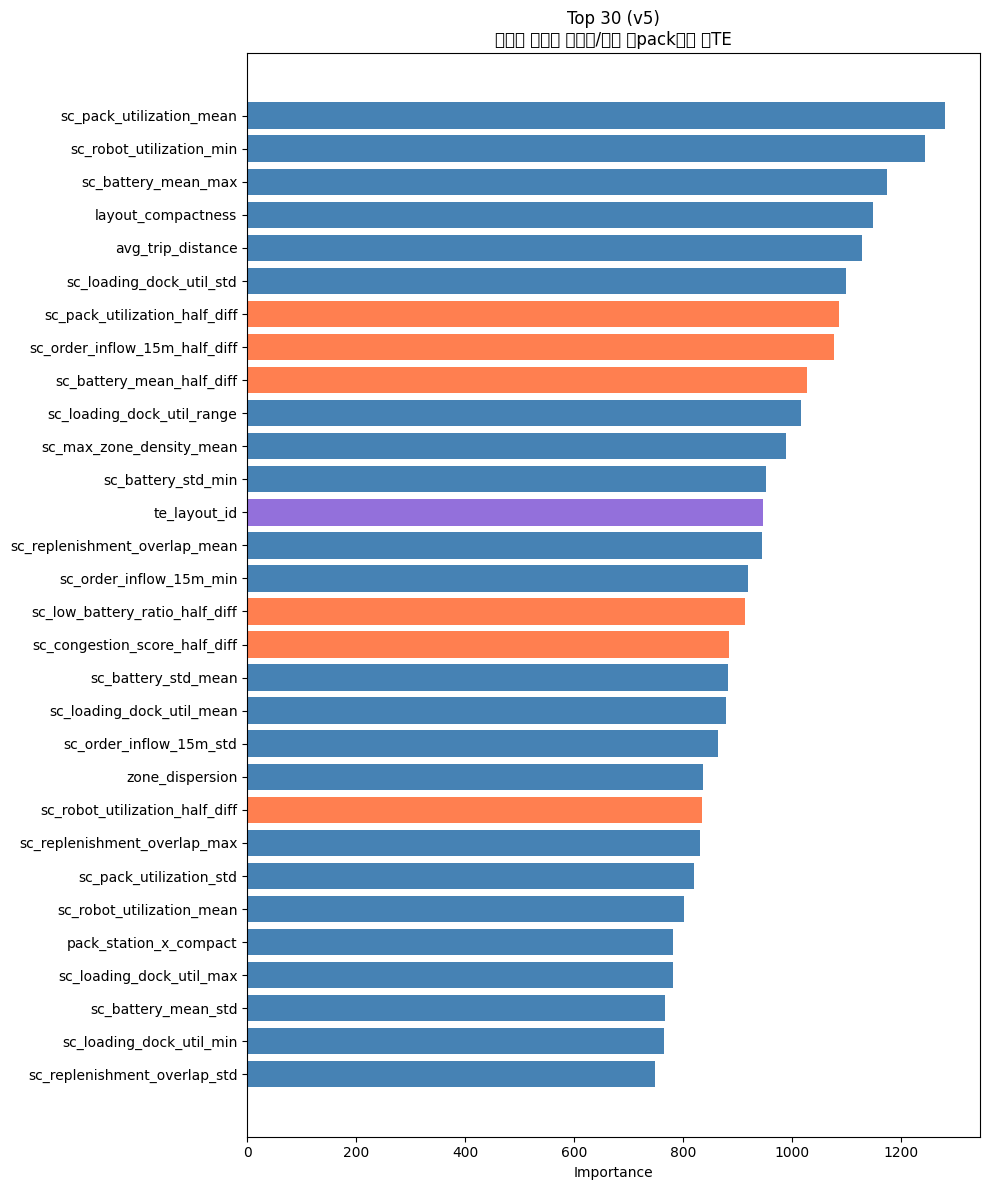

                      feature  importance
     sc_pack_utilization_mean      1281.0
     sc_robot_utilization_min      1243.2
          sc_battery_mean_max      1173.8
           layout_compactness      1148.0
            avg_trip_distance      1128.4
     sc_loading_dock_util_std      1100.0
sc_pack_utilization_half_diff      1086.2
sc_order_inflow_15m_half_diff      1076.2
    sc_battery_mean_half_diff      1027.6
   sc_loading_dock_util_range      1017.2
     sc_max_zone_density_mean       988.2
           sc_battery_std_min       951.8
                 te_layout_id       947.6
sc_replenishment_overlap_mean       944.0
      sc_order_inflow_15m_min       919.2


In [20]:
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': lgb_imp}).sort_values('importance', ascending=False).reset_index(drop=True)
top30 = imp_df.head(30)
def gc(n):
    if '_lag' in n or '_diff' in n: return 'coral'
    if any(t in n for t in ['_cumsum','_roll3','_exp_','_trend','slot_']): return 'mediumseagreen'
    if 'pack_sat' in n or 'pack_overflow' in n or 'pack_util_sq' in n: return 'gold'
    if 'te_' in n: return 'mediumpurple'
    return 'steelblue'
fig, ax = plt.subplots(figsize=(10,12))
ax.barh(top30['feature'][::-1], top30['importance'][::-1], color=top30['feature'].map(gc)[::-1])
ax.set_xlabel('Importance'); ax.set_title('Top 30 (v5)\n🔵원본 🟠래그 🟢누적/롤링 🟡pack임계 🟣TE')
plt.tight_layout(); plt.savefig('./feature_importance_v5.png', dpi=150, bbox_inches='tight'); plt.show()
print(imp_df.head(15)[['feature','importance']].to_string(index=False))

## 16. 제출

In [21]:
sub = pd.read_csv('./data/sample_submission.csv').drop(columns=[TARGET], errors='ignore')
sub = sub.merge(pd.DataFrame({'ID': test_fe['ID'], TARGET: final_preds}), on='ID', how='left')
sub.to_csv('./submission_v5.3.csv', index=False)
print('✅ submission_v5.3.csv 저장')
print(sub[TARGET].describe())
print(f'\n  95%: {np.percentile(final_preds,95):.1f}')
print(f'  99%: {np.percentile(final_preds,99):.1f}')
print(f'  max: {final_preds.max():.1f}')

✅ submission_v5.3.csv 저장
count    50000.000000
mean        19.382618
std         14.225307
min          0.346656
25%          5.582181
50%         14.858342
75%         33.760519
max         82.347189
Name: avg_delay_minutes_next_30m, dtype: float64

  95%: 39.5
  99%: 47.7
  max: 82.3
